In [1]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
# CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-pvv361bc"
# CHECKPOINT_FILE = "step_180.pt"
# EXP_NAME = "CIFAR10"

CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-a2rwqque"
CHECKPOINT_FILE = "step_10000.pt"
EXP_NAME = "MNIST"


## 1  FPCA Checkpoint — Setup

Load a checkpoint produced by `fpca.py` with either the
`dwsnets_mnist_eulerian` or `implicit_zoo_cifar_eulerian` experiment config.
All architecture and data-path details are read from the saved `config.yaml`.

In [2]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

In [3]:

# ── Set checkpoint path ────────────────────────────────────────────────────────

# MNIST INR
# CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-3se7flm0"   
# CHECKPOINT_FILE = "step_10000.pt"  


# MNIST INR large scale
# CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-a2rwqque"   
# CHECKPOINT_FILE = "step_10000.pt"  

# CIFAR INR
# CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-ls4absyf"   # MNIST INR
# CHECKPOINT_FILE = "step_7800.pt"                       

# CIFAR INR large scale
# CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-39iw3oae"   # MNIST INR
# CHECKPOINT_FILE = "step_2170.pt"      

# ──────────────────────────────────────────────────────────────────────────────

import os, yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets.inr import (
    _eval_siren_batch, ImplicitZooMNISTDataset, ImplicitZooCIFARDataset,
)
from infidictionary.neural_isometries import NeuralIsometry
from infidictionary.networks import NeuralField
from infidictionary.dictionaries import InfiDictionary
from infidictionary.domain_samplers import SquareSampler
from infidictionary.utils import pairwise_inner_product
from notebook_helpers import (
    plot_atom_mosaic, plot_atoms_comparison, show_field, visualize_generator_U,
    psnr_matrix, plot_psnr_line_chart, plot_spectral_compactness,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

# Fix data paths: config stores paths relative to project root; notebook is in notebooks/
_fg = conf.function_generator
for _key in ("data_dir", "zip_path"):
    if OmegaConf.select(_fg, _key) is not None:
        OmegaConf.update(conf, f"function_generator.{_key}",
                         os.path.join("..", str(OmegaConf.select(_fg, _key))), merge=True)

# ── Optionally cap the number of loaded INRs to speed things up ───────────────
# OmegaConf.update(conf, "function_generator.n_inrs", 500, merge=True)

neural_isometry: NeuralIsometry    = instantiate(conf.neural_isometry).to(device)
mean_function:   NeuralField       = instantiate(conf.mean_function).to(device)
initial_dictionary: InfiDictionary = instantiate(conf.initial_dictionary)
function_generator                 = instantiate(conf.function_generator)

ckpt = torch.load(
    f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False
)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
mean_function.load_state_dict(ckpt["models"]["mean_function"])

model_state_kwargs = OmegaConf.to_container(
    conf.get("model_state_kwargs", {"num_steps": 200}), resolve=True
)
pullback_kwargs = OmegaConf.to_container(
    conf.get("pullback_pushforward_kwargs", {}), resolve=True
)

neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()
mean_function.eval()

CHANNELS_DIM = int(conf.initial_dictionary.get("num_channels", 1))
CMAP = "Greys_r"   # plot_atom_mosaic ignores cmap for C>1 (uses RGB auto)

print(f"Loaded  : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  epoch={ckpt['epoch']}")
print(f"Metric  : {ckpt['metric']:.4f}  |  best: {ckpt['best_metric']:.4f}")
print(f"Dataset : {type(function_generator).__name__}  n_inrs={function_generator.n_inrs}  C={CHANNELS_DIM}")

from infidictionary.neural_isometries import IdentityIsometry
from infidictionary.recon import get_reconstructions
from notebook_helpers import plot_recon_grid

def eval_inrs_at_coords(fg, coords_01, num_elements, seed, dev):
    """Randomly sample num_elements SIRENs and evaluate at coords in [0,1]² → (num_elements, N, C)."""
    n_total = fg.weights[0].shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_total, size=min(num_elements, n_total), replace=False)
    sc = torch.stack([
        2.0 * coords_01[:, 0] - 1.0,
        1.0 - 2.0 * coords_01[:, 1],
    ], dim=-1).to(dev)
    w  = [W[idx].to(dev) for W in fg.weights]
    b  = [bb[idx].to(dev) for bb in fg.biases]
    from infidictionary.datasets.inr import _eval_siren_batch
    with torch.no_grad():
        return _eval_siren_batch(sc, w, b, fg.omega_0, fg.omega)

Device: cuda
Loaded  : ../outputs/checkpoints/wandb-a2rwqque/step_10000.pt  epoch=9999
Metric  : 0.0040  |  best: 0.0124
Dataset : ImplicitZooMNISTDataset  n_inrs=1024  C=1


## 2  Sample Batch Gallery

A quick look at what the loaded `function_generator` actually contains.
MNIST uses hexbin (C=1, grayscale); CIFAR-10 uses RGB scatter (C=3).

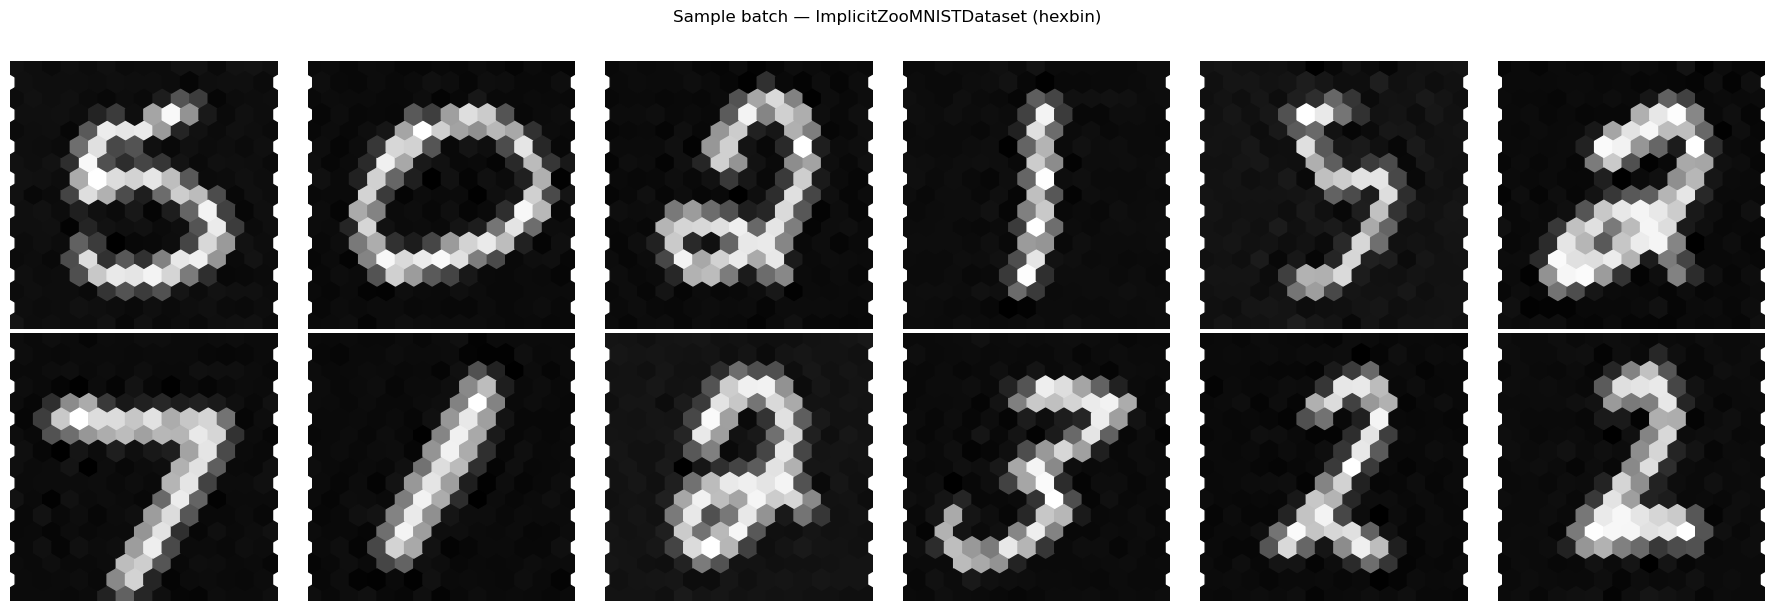

In [4]:
n_show = 12
function_generator.reset_buffer()
c_b, v_b = function_generator.get_batch(n_show)   # coords in [0,1]²
xy_b = c_b.detach().cpu().numpy()                  # display in [0,1]²

fig, axes = plt.subplots(2, n_show // 2, figsize=(18, 6))

if CHANNELS_DIM == 1:
    for i, ax in enumerate(axes.flat):
        vals_i = v_b[i, :, 0].detach().cpu().numpy()
        ax.hexbin(xy_b[:, 0], xy_b[:, 1], C=vals_i,
                  gridsize=14, cmap='gray', reduce_C_function=np.mean)
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_aspect('equal'); ax.axis('off')
    plt.suptitle(f'Sample batch — {type(function_generator).__name__} (hexbin)', y=1.01)
else:
    for i, ax in enumerate(axes.flat):
        rgb = v_b[i].detach().cpu().numpy()   # (N, 3)
        rgb_norm = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
        ax.scatter(xy_b[:, 0], xy_b[:, 1], c=rgb_norm, s=50, alpha=0.7)
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.set_aspect('equal'); ax.axis('off')
    plt.suptitle(f'Sample batch — {type(function_generator).__name__} (RGB scatter)', y=1.01)

plt.tight_layout()
plt.show()

### Learned Mean Function $\mu(x)$

Co-trained with the isometry; minimises MSE to the dataset mean.
The isometry then diagonalises the covariance of the *zero-centred* data.

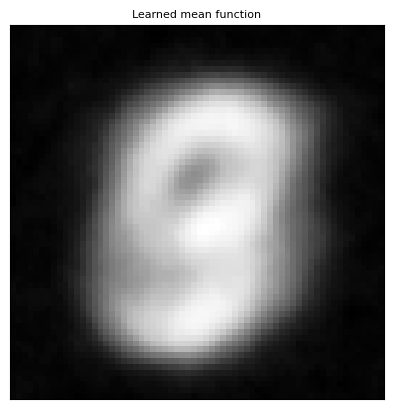

In [5]:
N_MEAN = 64
coords_mean = SquareSampler(stratified=True, add_noise=False).sample(N_MEAN).to(device)
with torch.no_grad():
    mean_vals = mean_function(coords_mean)   # (N, C)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
show_field(ax, mean_vals, N_MEAN, title="Learned mean function", cmap=CMAP)
plt.tight_layout(); plt.show()

## 3  Learned Basis — Fourier Atoms vs. Pushed-Forward Atoms

Evaluate each truncated Fourier atom $\varphi_{k_1,k_2}$ and its learned
counterpart $Q\varphi_{k_1,k_2}$ on a regular grid.
Grayscale for MNIST ($C=1$); separate R/G/B panels for CIFAR ($C=3$).

The atom mosaic is the primary visual diagnostic: if the isometry has
converged, the pushed-forward atoms should look like data-adapted basis
functions (e.g. edges, blobs, colour patches) rather than pure Fourier modes.

Showing 81 atoms  (N_TRUNC=5, C=1)


/home/hamid/projects/learning-projections/notebooks/notebook_helpers.py:390: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


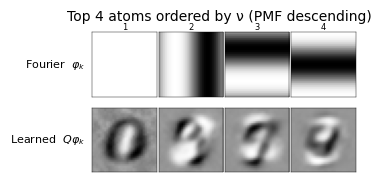

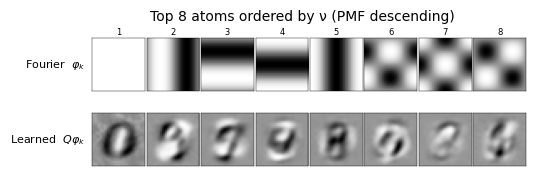

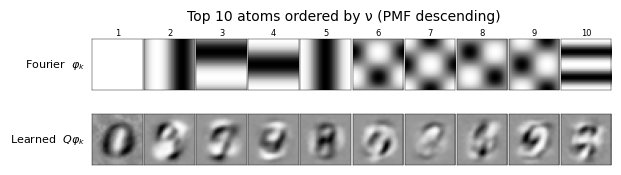

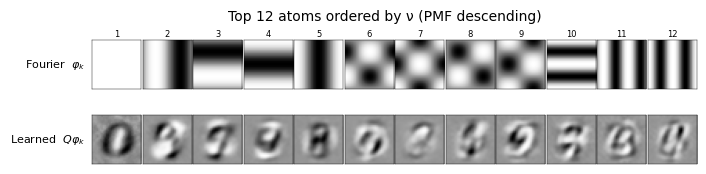

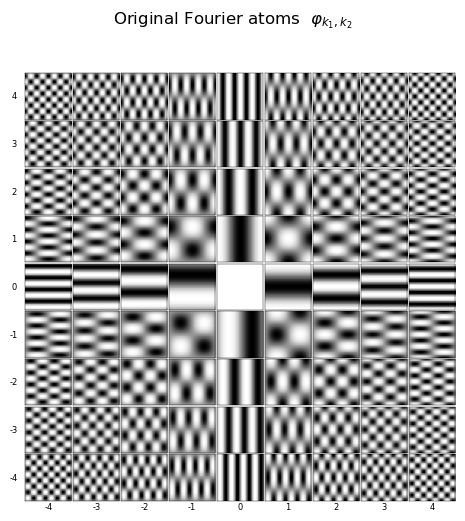

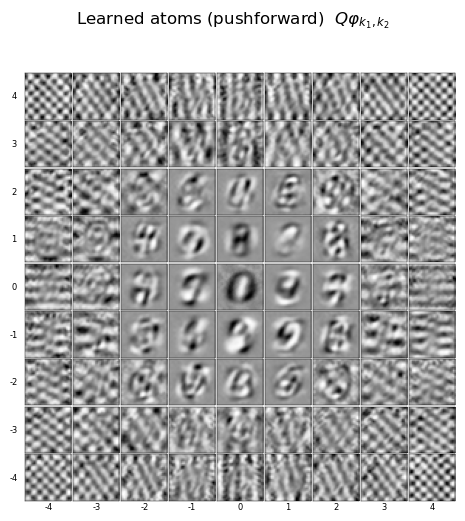

In [6]:
N_VIS_ATOMS = 32   # resolution of each tile (N_VIS_ATOMS² grid points)
N_TRUNC     =  5   # show atoms with |k|_∞ ≤ N_TRUNC-1  →  (2*N_TRUNC-1)² atoms per channel

coords_atoms = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_ATOMS).to(device)
lad_atoms    = torch.zeros(coords_atoms.shape[0], device=device)

# Sort by PMF ν descending so the linear layout is ν-ordered
indices_all = initial_dictionary.get_truncated_indices(N_TRUNC).to(device)
nu_all      = initial_dictionary.get_index_pmfs(indices_all)
order_nu    = nu_all.argsort(descending=True)
indices_nu  = indices_all[order_nu]
print(f"Showing {indices_nu.shape[0]} atoms  (N_TRUNC={N_TRUNC}, C={CHANNELS_DIM})")

neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_src = initial_dictionary.get_atoms(coords_atoms, indices_nu)       # (A, N, C)
    _, _, atoms_tgt = neural_isometry.pushforward(
        coords_atoms, lad_atoms, atoms_src, **pullback_kwargs,
    )                                                                         # (A, N, C)

# ── 2-row linear comparison (ν-ordered) ──────────────────────────────────────
for n_show_linear in [4, 8, 10, 12]:
    plot_atoms_comparison(
        atoms_src.cpu(), atoms_tgt.cpu(),
        n_vis=N_VIS_ATOMS, n_show=n_show_linear, tile_size=0.55, cmap=CMAP,
        title=f"Top {n_show_linear} atoms ordered by ν (PMF descending)",
    )

# ── 2D grid mosaic (k₁ × k₂ layout, both bases) ──────────────────────────────
plot_atom_mosaic(
    atoms_src.cpu(), indices_nu.cpu(),
    title=r"Original Fourier atoms  $\varphi_{k_1,k_2}$",
    n_vis=N_VIS_ATOMS, tile_size=0.55, cmap=CMAP,
)
plot_atom_mosaic(
    atoms_tgt.cpu(), indices_nu.cpu(),
    title=r"Learned atoms (pushforward)  $Q\varphi_{k_1,k_2}$",
    n_vis=N_VIS_ATOMS, tile_size=0.55, cmap=CMAP,
)


## 4  Reconstruction — In-Distribution

Truncated reconstruction in the **Fourier** basis vs. the **learned** basis $\{Q\varphi_k\}$ at several atom budgets. PSNR (dB) shown above each tile.

In-distribution signals: (4, 1024, 1)
Truncations [1, 2, 3, 4, 8]  ->  [1, 9, 25, 49, 225] atoms


/home/hamid/projects/learning-projections/notebooks/notebook_helpers.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


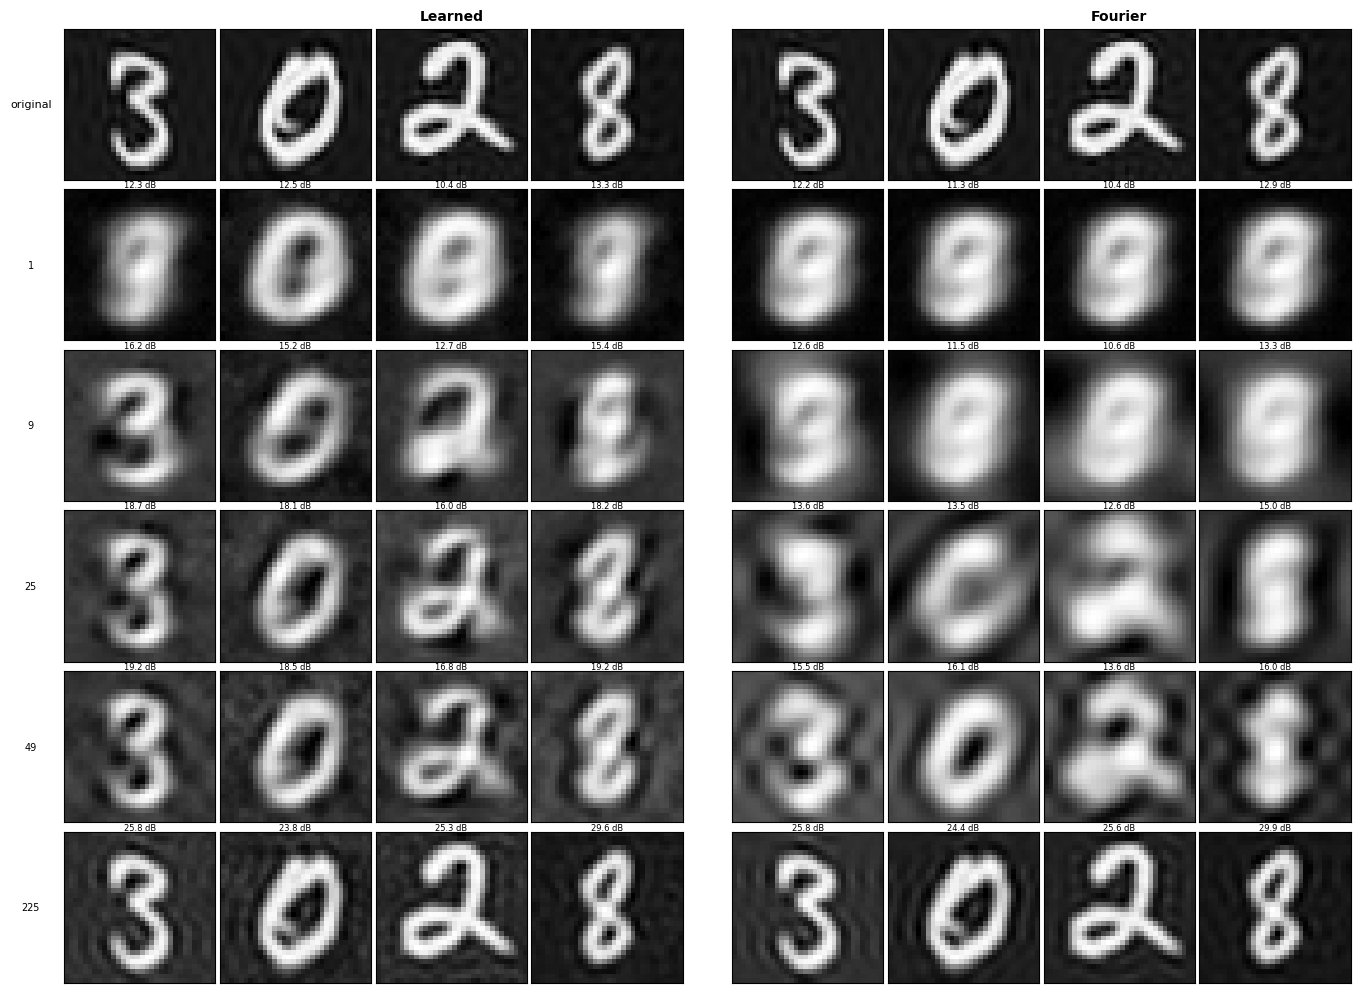

In [7]:
N_VAL       = 4
if EXP_NAME == "CIFAR10":
    TRUNCATIONS = [2, 3, 5, 8, 10] # , 6, 10]
else:
    TRUNCATIONS = [1, 2, 3, 4, 8]

N_RECON      = 32
coords_recon = SquareSampler(stratified=True, add_noise=False).sample(N_RECON).to(device)
lad_recon    = torch.zeros(coords_recon.shape[0], device=device)

val_in = eval_inrs_at_coords(function_generator, coords_recon, N_VAL, 42, device)
print(f"In-distribution signals: {tuple(val_in.shape)}")

n_atoms_list = [initial_dictionary.get_truncated_indices(t).shape[0] for t in TRUNCATIONS]
print(f"Truncations {TRUNCATIONS}  ->  {n_atoms_list} atoms")

identity_iso = IdentityIsometry().to(device).eval()
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    fourier_recons_in = [
        get_reconstructions(coords_recon, val_in, identity_iso, mean_function,
                            initial_dictionary, t, **pullback_kwargs).cpu()
        for t in TRUNCATIONS
    ]
    learned_recons_in = [
        get_reconstructions(coords_recon, val_in, neural_isometry, mean_function,
                            initial_dictionary, t, **pullback_kwargs).cpu()
        for t in TRUNCATIONS
    ]

metrics_in = plot_recon_grid(
    methods=[("Learned", learned_recons_in), ("Fourier", fourier_recons_in)],
    val_imgs_cpu=val_in.cpu(),
    n_atoms_list=n_atoms_list,
    n=N_RECON,
    cmap=CMAP,
)

## 5  Reconstruction — Out-of-Distribution

Held-out SIRENs (MNIST test split or CIFAR-10 eval split). The `ood_fg` object is reused by the spectral compactness section below.

In [8]:
fg_cfg = conf.function_generator
# Paths in fg_cfg are already prefixed with '../' by the fix in section 1.

if isinstance(function_generator, ImplicitZooMNISTDataset):
    try:
        ood_fg = ImplicitZooMNISTDataset(
            data_dir=str(fg_cfg.data_dir),
            filter_pattern="mnist_png_testing*",
            n_inrs=max(N_VAL, 200),
            omega_0=float(fg_cfg.get("omega_0", 30.0)),
            omega=float(fg_cfg.get("omega", 30.0)),
            device=device,
        )
        ood_label = "MNIST test split"
    except FileNotFoundError as exc:
        print(f"Could not load OOD MNIST: {exc}")
        ood_fg = None
        ood_label = None
elif isinstance(function_generator, ImplicitZooCIFARDataset):
    ood_fg = ImplicitZooCIFARDataset(
        zip_path=str(fg_cfg.zip_path),
        split="eval",
        n_inrs=max(N_VAL, 200),
        omega_0=float(fg_cfg.get("omega_0", 30.0)),
        omega=float(fg_cfg.get("omega", 30.0)),
        device=device,
    )
    ood_label = "CIFAR-10 eval split"
else:
    ood_fg = None
    ood_label = None
    print("Unknown generator type — OOD skipped.")

if ood_fg is not None:
    print(f"OOD: {ood_label}  n_inrs={ood_fg.n_inrs}")

OOD: MNIST test split  n_inrs=200


OOD signals: (4, 1024, 1)


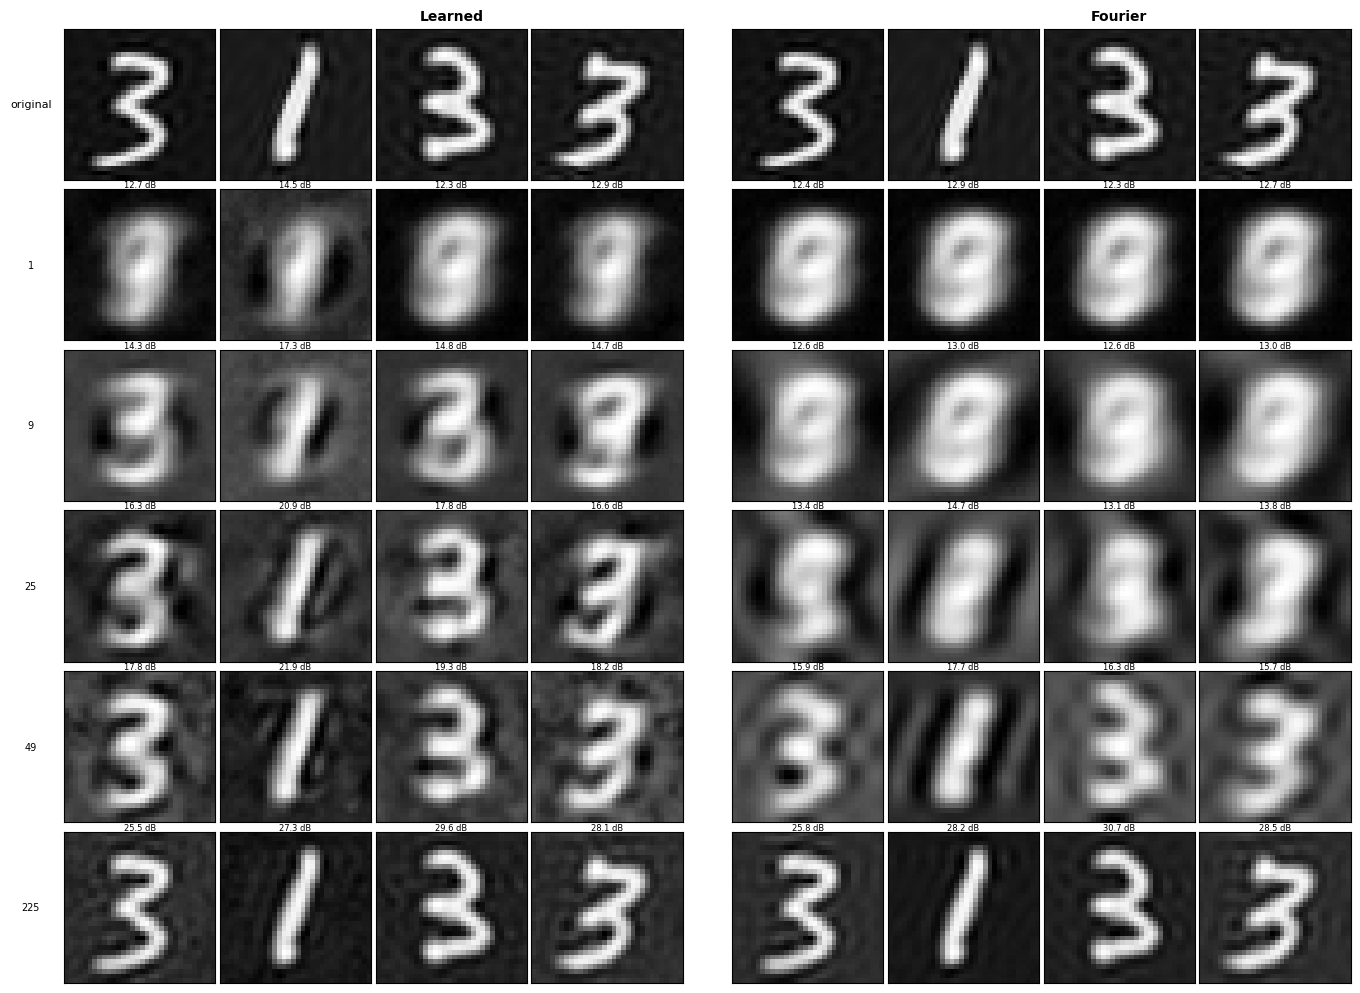

In [9]:
if ood_fg is not None:
    val_ood = eval_inrs_at_coords(ood_fg, coords_recon, N_VAL, 0, device)
    print(f"OOD signals: {tuple(val_ood.shape)}")

    neural_isometry.shuffle_model_state(**model_state_kwargs)
    neural_isometry.eval()

    with torch.no_grad():
        fourier_recons_ood = [
            get_reconstructions(coords_recon, val_ood, identity_iso, mean_function,
                                initial_dictionary, t, **pullback_kwargs).cpu()
            for t in TRUNCATIONS
        ]
        learned_recons_ood = [
            get_reconstructions(coords_recon, val_ood, neural_isometry, mean_function,
                                initial_dictionary, t, **pullback_kwargs).cpu()
            for t in TRUNCATIONS
        ]

    metrics_ood = plot_recon_grid(
        methods=[("Learned", learned_recons_ood), ("Fourier", fourier_recons_ood)],
        val_imgs_cpu=val_ood.cpu(),
        n_atoms_list=n_atoms_list,
        n=N_RECON,
        cmap=CMAP,
    )

## PSNR vs. Number of Atoms

Bar chart summarising reconstruction quality for every signal and truncation level, with one panel per signal. In-distribution (top) and OOD (bottom, if available).

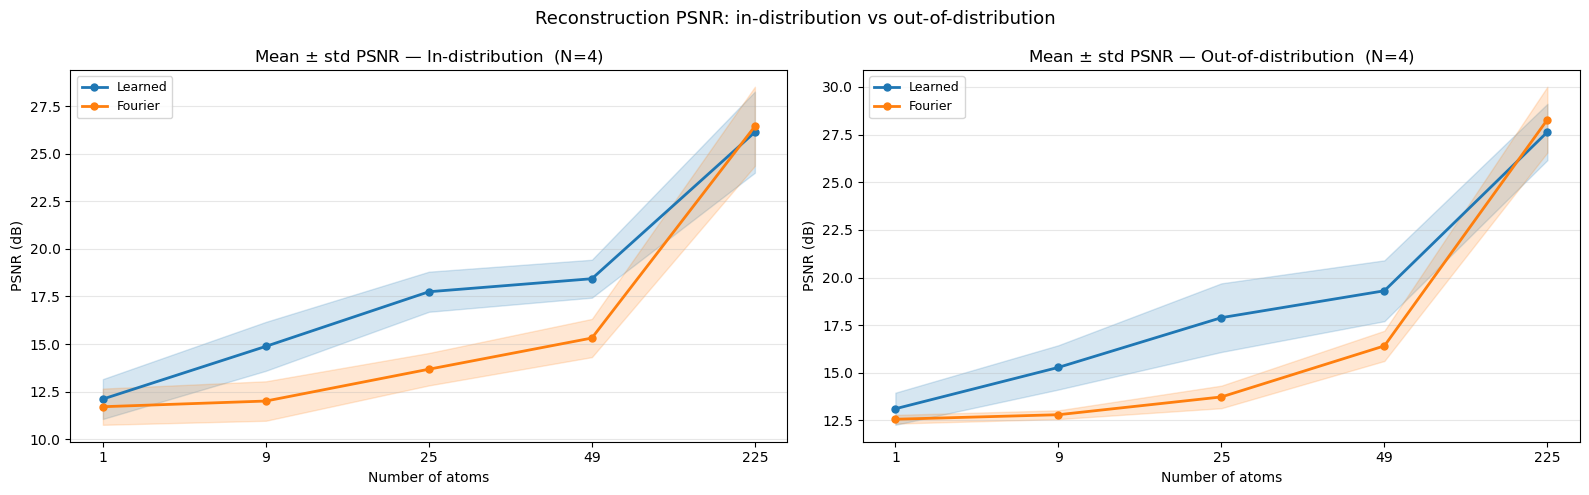

In [10]:
psnr_in_F = psnr_matrix(fourier_recons_in, val_in.cpu())  # (N_VAL, K)
psnr_in_L = psnr_matrix(learned_recons_in, val_in.cpu())

in_methods = [("Learned", psnr_in_L), ("Fourier", psnr_in_F)]

if ood_fg is not None:
    psnr_ood_F = psnr_matrix(fourier_recons_ood, val_ood.cpu())
    psnr_ood_L = psnr_matrix(learned_recons_ood, val_ood.cpu())
    ood_methods = [("Learned", psnr_ood_L), ("Fourier", psnr_ood_F)]
else:
    ood_methods = None

plot_psnr_line_chart(
    in_methods=in_methods,
    n_atoms_list=n_atoms_list,
    ood_methods=ood_methods,
)


## 6  Spectral Compactness — In-Distribution

For each of `N_SPEC` training-split SIRENs, compute the squared projection
coefficients

$$c_k^F = \langle f - \mu,\, \varphi_k\rangle, \qquad
  c_k^L = \langle Q^*(f - \mu),\, \varphi_k\rangle,$$

atoms ordered by $\nu(k)$ (prior PMF) descending.  If FPCA has converged,
the learned basis should pack more energy into the first few atoms.

In [11]:
N_SPEC     = 200   # SIRENs to average over
K_SPEC     = 12    # Fourier half-bandwidth: (2K-1)² atoms per channel
N_VIS_SPEC = 32    # grid resolution for inner products

coords_spec = SquareSampler(stratified=True, add_noise=False).sample(N_VIS_SPEC).to(device)
lad_spec    = torch.zeros(coords_spec.shape[0], device=device)

# Atoms sorted by ν descending
spec_idx = initial_dictionary.get_truncated_indices(K_SPEC).to(device)
spec_nu  = initial_dictionary.get_index_pmfs(spec_idx)
order    = spec_nu.argsort(descending=True)
spec_idx = spec_idx[order]
spec_nu  = spec_nu[order].cpu()
A_spec   = spec_idx.shape[0]
print(f"{A_spec} atoms  ν ∈ [{spec_nu[-1]:.2e}, {spec_nu[0]:.2e}]")

# Evaluate training SIRENs on the fixed grid
imgs_in = eval_inrs_at_coords(function_generator, coords_spec, N_SPEC, 0, device)
print(f"In-distribution signals: {tuple(imgs_in.shape)}")

529 atoms  ν ∈ [5.24e-06, 3.10e-01]
In-distribution signals: (200, 1024, 1)


In [12]:
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval()

with torch.no_grad():
    mu_spec = mean_function(coords_spec)                                     # (N, C)
    ctr_in  = imgs_in - mu_spec.unsqueeze(0)                                 # (n_in, N, C)

    atoms_tgt_spec = initial_dictionary.get_atoms(coords_spec, spec_idx)     # (A, N, C)
    c_F_in  = pairwise_inner_product(atoms_tgt_spec, ctr_in, lad_spec)       # (A, n_in)

    src_c_in, src_l_in, pulled_in = neural_isometry.pullback(
        tgt_coords=coords_spec, tgt_logabsdet=lad_spec, tgt_field=ctr_in,
        **pullback_kwargs,
    )
    atoms_src_spec = initial_dictionary.get_atoms(src_c_in, spec_idx)        # (A, N_src, C)
    c_L_in  = pairwise_inner_product(atoms_src_spec, pulled_in, src_l_in)    # (A, n_in)

sq_F_in = c_F_in.pow(2).cpu()   # (A, n_in)
sq_L_in = c_L_in.pow(2).cpu()
e_F_in  = sq_F_in.mean(-1)      # (A,) mean squared coeff per atom
e_L_in  = sq_L_in.mean(-1)
print(f"Total energy (in-dist) — Fourier: {e_F_in.sum():.4f}  Learned: {e_L_in.sum():.4f}")

Total energy (in-dist) — Fourier: 0.0692  Learned: 0.0693


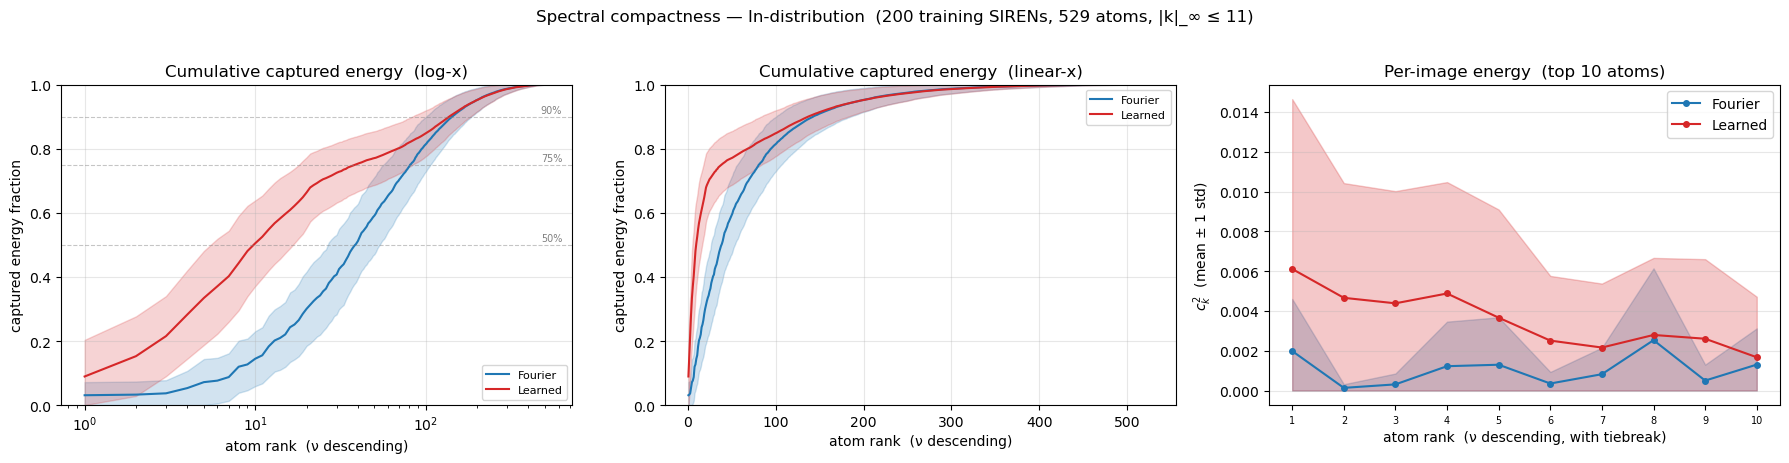


 Threshold     Fourier     Learned      gain
       50%         39         10    +74.4%
       75%         81         39    +51.9%
       90%        143        138     +3.5%


In [13]:
N_VIOLIN = 10   # how many top-ν atoms to show in the per-atom panel

# Per-image cumulative fraction of total energy: (A, n_in)
cum_F_in_per_img = sq_F_in.cumsum(0) / (sq_F_in.sum(0, keepdim=True) + 1e-15)
cum_L_in_per_img = sq_L_in.cumsum(0) / (sq_L_in.sum(0, keepdim=True) + 1e-15)

cum_F_in_mean = cum_F_in_per_img.mean(dim=1).numpy()
cum_F_in_std  = cum_F_in_per_img.std(dim=1).numpy()
cum_L_in_mean = cum_L_in_per_img.mean(dim=1).numpy()
cum_L_in_std  = cum_L_in_per_img.std(dim=1).numpy()

x_in = np.arange(1, A_spec + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

plot_spectral_compactness(
    [
        dict(label="Fourier", xs=x_in, mean=cum_F_in_mean, std=cum_F_in_std, color='C0'),
        dict(label="Learned", xs=x_in, mean=cum_L_in_mean, std=cum_L_in_std, color='C3'),
    ],
    xlabel="atom rank  (ν descending)",
    xscale="log",
    axes=(axes[0], axes[1]),
)

# ── Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────────
ax  = axes[2]
nv  = min(N_VIOLIN, A_spec)
pos = np.arange(1, nv + 1)

mean_F_in = sq_F_in[:nv].mean(dim=-1).numpy()
std_F_in  = sq_F_in[:nv].std(dim=-1).numpy()
mean_L_in = sq_L_in[:nv].mean(dim=-1).numpy()
std_L_in  = sq_L_in[:nv].std(dim=-1).numpy()

ax.plot(pos, mean_F_in, 'o-', lw=1.5, ms=4, color='C0', label="Fourier")
ax.fill_between(pos, np.maximum(mean_F_in - std_F_in, 0), mean_F_in + std_F_in,
                alpha=0.25, color='C0')
ax.plot(pos, mean_L_in, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
ax.fill_between(pos, np.maximum(mean_L_in - std_L_in, 0), mean_L_in + std_L_in,
                alpha=0.25, color='C3')
ax.set_xticks(pos)
ax.set_xticklabels([str(k) for k in pos], fontsize=7)
ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
ax.set_title(f"Per-image energy  (top {nv} atoms)")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Spectral compactness — In-distribution  "
    f"({imgs_in.shape[0]} training SIRENs, {A_spec} atoms, |k|_∞ ≤ {K_SPEC - 1})",
    y=1.02,
)
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"\n{'Threshold':>10}  {'Fourier':>10}  {'Learned':>10}  {'gain':>8}")
for frac in [0.50, 0.75, 0.90]:
    nf = int((cum_F_in_mean < frac).sum()) + 1
    nl = int((cum_L_in_mean < frac).sum()) + 1
    gain = (nf - nl) / max(nf, 1) * 100
    print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")


## 7  Spectral Compactness — Out-of-Distribution

Load held-out SIRENs and repeat the spectral analysis:

| Training dataset | OOD source |
|---|---|
| `ImplicitZooMNISTDataset` | `mnist_png_testing*` (MNIST test split) |
| `ImplicitZooCIFARDataset` | `split='eval'` (10 000 held-out CIFAR-10 SIRENs) |

A well-trained FPCA basis should generalise: the learned representation should
remain compact on held-out data from the same distribution.

OOD signals for spectral: (200, 1024, 1)
Total energy (OOD) — Fourier: 0.0673  Learned: 0.0675


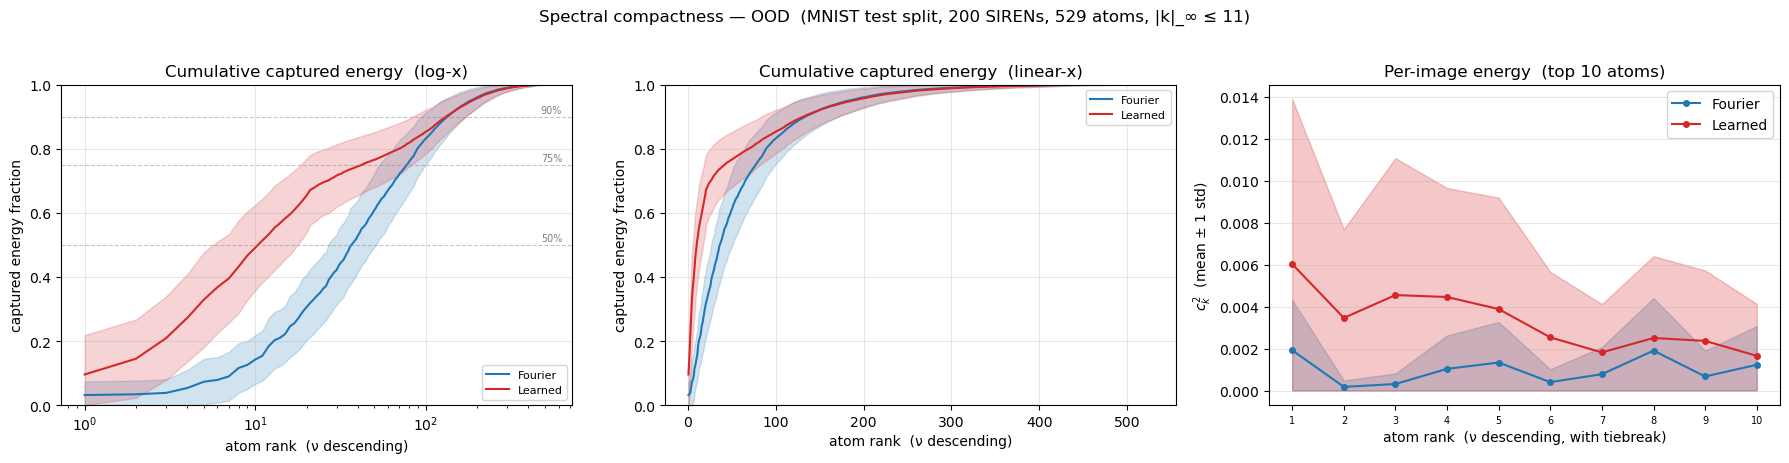


 Threshold     Fourier     Learned      gain
       50%         37         11    +70.3%
       75%         78         43    +44.9%
       90%        135        132     +2.2%


In [14]:
if ood_fg is not None:
    imgs_ood = eval_inrs_at_coords(ood_fg, coords_spec, N_SPEC, 0, device)
    print(f"OOD signals for spectral: {tuple(imgs_ood.shape)}")
    neural_isometry.shuffle_model_state(**model_state_kwargs)
    neural_isometry.eval()

    with torch.no_grad():
        ctr_ood = imgs_ood - mu_spec.unsqueeze(0)                                # (n_ood, N, C)

        c_F_ood = pairwise_inner_product(atoms_tgt_spec, ctr_ood, lad_spec)      # (A, n_ood)

        src_c_o, src_l_o, pulled_ood = neural_isometry.pullback(
            tgt_coords=coords_spec, tgt_logabsdet=lad_spec, tgt_field=ctr_ood,
            **pullback_kwargs,
        )
        atoms_src_ood = initial_dictionary.get_atoms(src_c_o, spec_idx)          # (A, N_src, C)
        c_L_ood = pairwise_inner_product(atoms_src_ood, pulled_ood, src_l_o)     # (A, n_ood)

    sq_F_ood = c_F_ood.pow(2).cpu()
    sq_L_ood = c_L_ood.pow(2).cpu()
    e_F_ood  = sq_F_ood.mean(-1)
    e_L_ood  = sq_L_ood.mean(-1)
    print(f"Total energy (OOD) — Fourier: {e_F_ood.sum():.4f}  Learned: {e_L_ood.sum():.4f}")

    # Per-image cumulative fraction of total energy: (A, n_ood)
    cum_F_ood_per_img = sq_F_ood.cumsum(0) / (sq_F_ood.sum(0, keepdim=True) + 1e-15)
    cum_L_ood_per_img = sq_L_ood.cumsum(0) / (sq_L_ood.sum(0, keepdim=True) + 1e-15)

    cum_F_ood_mean = cum_F_ood_per_img.mean(dim=1).numpy()
    cum_F_ood_std  = cum_F_ood_per_img.std(dim=1).numpy()
    cum_L_ood_mean = cum_L_ood_per_img.mean(dim=1).numpy()
    cum_L_ood_std  = cum_L_ood_per_img.std(dim=1).numpy()

    x_ood = np.arange(1, A_spec + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    plot_spectral_compactness(
        [
            dict(label="Fourier", xs=x_ood, mean=cum_F_ood_mean, std=cum_F_ood_std, color='C0'),
            dict(label="Learned", xs=x_ood, mean=cum_L_ood_mean, std=cum_L_ood_std, color='C3'),
        ],
        xlabel="atom rank  (ν descending)",
        xscale="log",
        axes=(axes[0], axes[1]),
    )

    # ── Per-atom mean ± std  (top N_VIOLIN atoms) ─────────────────────────
    ax  = axes[2]
    nv  = min(N_VIOLIN, A_spec)
    pos = np.arange(1, nv + 1)

    mean_F_ood = sq_F_ood[:nv].mean(dim=-1).numpy()
    std_F_ood  = sq_F_ood[:nv].std(dim=-1).numpy()
    mean_L_ood = sq_L_ood[:nv].mean(dim=-1).numpy()
    std_L_ood  = sq_L_ood[:nv].std(dim=-1).numpy()

    ax.plot(pos, mean_F_ood, 'o-', lw=1.5, ms=4, color='C0', label="Fourier")
    ax.fill_between(pos, np.maximum(mean_F_ood - std_F_ood, 0), mean_F_ood + std_F_ood,
                    alpha=0.25, color='C0')
    ax.plot(pos, mean_L_ood, 'o-', lw=1.5, ms=4, color='C3', label="Learned")
    ax.fill_between(pos, np.maximum(mean_L_ood - std_L_ood, 0), mean_L_ood + std_L_ood,
                    alpha=0.25, color='C3')
    ax.set_xticks(pos)
    ax.set_xticklabels([str(k) for k in pos], fontsize=7)
    ax.set_xlabel("atom rank  (ν descending, with tiebreak)")
    ax.set_ylabel("$c_k^2$  (mean ± 1 std)")
    ax.set_title(f"Per-image energy  (top {nv} atoms)")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

    plt.suptitle(
        f"Spectral compactness — OOD  "
        f"({ood_label}, {imgs_ood.shape[0]} SIRENs, {A_spec} atoms, |k|_∞ ≤ {K_SPEC - 1})",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f"\n{'Threshold':>10}  {'Fourier':>10}  {'Learned':>10}  {'gain':>8}")
    for frac in [0.50, 0.75, 0.90]:
        nf = int((cum_F_ood_mean < frac).sum()) + 1
        nl = int((cum_L_ood_mean < frac).sum()) + 1
        gain = (nf - nl) / max(nf, 1) * 100
        print(f"{frac*100:>9.0f}%  {nf:>9d}  {nl:>9d}  {gain:>+7.1f}%")